# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Research Question

Can historical search performance and engagement metrics be used to identify content that should be refreshed?

## Decision Supported

This project supports content managers in prioritizing pages for review by ranking content based on observed search performance trends and engagement metrics.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# Data

Dataset: FlyRank ML Internship Warehouse

Tables Used:
- fact_content_daily_performance
- dim_content (if needed)

Date Window:
- Example: January 2025 to March 2026

Excluded Data:
- Records with missing content identifiers
- Records with zero impressions where CTR cannot be interpreted
- No client names, URLs, or search queries were used.

#Import Libraries

In [54]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import login, hf_hub_download
from google.colab import userdata


#Login to Hugging Face

In [55]:
login(userdata.get("HF_TOKEN"))

#Load Dataset

In [56]:
parquet_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet"
)

con = duckdb.connect()

df = con.execute(f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_pageviews,
    ga4_sessions,
    ga4_users,
    ga4_engaged_sessions,
    ga4_total_engagement_sec
FROM read_parquet('{parquet_file}')
""").fetch_df()

print(df.shape)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(9841378, 11)


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,20,0,3.350000,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,1,0,0.000000,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,125,1,4.928000,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,7,0,4.000000,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,11,0,2.272727,<NA>,<NA>,<NA>,<NA>,<NA>


#Verify Date Range

In [57]:
print("Start Date :", df["report_date"].min())
print("End Date   :", df["report_date"].max())

Start Date : 2026-03-01 00:00:00
End Date   : 2026-03-31 00:00:00


#Missing Values

In [58]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

,0
gsc_avg_position,6230317
ga4_pageviews,3018741
ga4_users,3018741
ga4_engaged_sessions,3018741
ga4_total_engagement_sec,3018741
ga4_sessions,3018741


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# Methodology

Features:
- GSC Impressions
- GSC Clicks
- Average Position
- GA4 Sessions
- Pageviews
- Engaged Sessions
- Engagement Time
- CTR

Label

Content Opportunity Score

Baseline

Rank pages only by impressions.

Model

Random Forest Regressor (ya scoring approach)

Validation

Time-based split to avoid data leakage.

Leakage Checks

No future information was used while creating features.

#Create CTR

In [59]:
df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    0
)

df[["gsc_clicks", "gsc_impressions", "ctr"]].head()

,gsc_clicks,gsc_impressions,ctr
0,0,20,0.000
1,0,1,0.000
2,1,125,0.008
3,0,7,0.000
4,0,11,0.000


#Basic Cleaning

In [60]:
selected_columns = [
    "report_date",
    "content_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "ctr"
]

df = df[selected_columns].copy()

df = df.drop_duplicates()

df = df.dropna(subset=["content_hash_id"])

print(df.shape)

(9841378, 11)


#Aggregate by Content

In [61]:
content_df = (
    df.groupby("content_hash_id")
      .agg({
          "gsc_impressions": "sum",
          "gsc_clicks": "sum",
          "gsc_avg_position": "mean",
          "ga4_pageviews": "sum",
          "ga4_sessions": "sum",
          "ga4_users": "sum",
          "ga4_engaged_sessions": "sum",
          "ga4_total_engagement_sec": "sum",
          "ctr": "mean"
      })
      .reset_index()
)

print(content_df.shape)

content_df.head()

(331437, 10)


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr
0,content_000005d4ced12088,86,0,72.854861,0,0,0,0,0,0.0
1,content_00001e488b74b799,0,0,NaN,0,0,0,0,0,0.0
2,content_00007bd2985b77c3,47,0,5.269565,0,0,0,0,0,0.0
3,content_00008950670cb6b5,0,0,NaN,2,2,2,1,48,0.0
4,content_0000a348850eb1fc,0,0,NaN,1,1,1,0,7,0.0


#Baseline Ranking

In [62]:
baseline = (
    content_df.sort_values(
        by="gsc_impressions",
        ascending=False
    )
)

baseline.head(10)

,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076
305658,content_ec2e0346994fb5a5,245276,1480,2.854514,873,816,772,90,21792,0.005706
301152,content_e8a52cf3d5988c07,244931,669,15.008339,1238,891,861,103,9557,0.002754
18156,content_0e03de7680314cd5,221310,720,2.675217,498,465,456,59,6704,0.004708
88955,content_44f34c0a90047651,212404,24,7.346909,46,37,37,1,211,0.001282
146628,content_7172a7fad43f0998,205867,862,3.367835,0,0,0,0,0,0.004412
299924,content_e7b5dd4dff461ad2,205045,2446,4.544203,0,0,0,0,0,0.013566
182881,content_8d7d99f109e19aa2,203497,289,2.563756,173,164,162,16,2111,0.003366
311926,content_f107e54b10b43725,195997,996,3.186054,0,0,0,0,0,0.005700
70658,content_36e53e9c707674fc,194579,242,32.766674,2767,2603,2626,35,5746,0.001297


#Create a Simple Content Opportunity Score

In [63]:
content_df["opportunity_score"] = (
    0.40 * (1 - content_df["ctr"]) +
    0.30 * (
        content_df["gsc_impressions"] /
        content_df["gsc_impressions"].max()
    ) +
    0.30 * (
        content_df["gsc_avg_position"] /
        content_df["gsc_avg_position"].max()
    )
)

#Top Content Refresh Opportunities

In [64]:
recommendations = (
    content_df
    .sort_values(
        by="opportunity_score",
        ascending=False
    )
    .head(20)
)

recommendations

,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr,opportunity_score
205205,content_9e8c3b83214c180d,1,0,309.000000,0,0,0,0,0,0.000000,0.700000
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076,0.698283
8166,content_06589faf15cc8488,1,0,297.000000,0,0,0,0,0,0.000000,0.688350
70522,content_36cc2bda86ee726a,1,0,292.000000,0,0,0,0,0,0.000000,0.683496
22138,content_11187e07e5ee9f43,1,0,286.000000,0,0,0,0,0,0.000000,0.677670
310341,content_efce4eda2b012964,1,0,283.000000,0,0,0,0,0,0.000000,0.674758
16691,content_0cec599cfeab8b7f,1,0,280.000000,0,0,0,0,0,0.000000,0.671845
126138,content_61b375eafb1d4c27,1,0,271.000000,0,0,0,0,0,0.000000,0.663107
326564,content_fc468c5940d16ea3,1,0,262.000000,0,0,0,0,0,0.000000,0.654369
71280,content_3758dd311e8033f7,1,0,260.000000,0,0,0,0,0,0.000000,0.652428


In [65]:
df.isnull().sum()

,0
report_date,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,6230317
ga4_pageviews,3018741
ga4_sessions,3018741
ga4_users,3018741
ga4_engaged_sessions,3018741
ga4_total_engagement_sec,3018741


In [66]:
numeric_cols = [
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec"
]

df[numeric_cols] = df[numeric_cols].fillna(0)

In [67]:
df["gsc_avg_position"] = df["gsc_avg_position"].fillna(
    df["gsc_avg_position"].median()
)

In [68]:
df = df.dropna(subset=["content_hash_id", "report_date"])

In [69]:
df.isnull().sum()

,0
report_date,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,0
ga4_pageviews,0
ga4_sessions,0
ga4_users,0
ga4_engaged_sessions,0
ga4_total_engagement_sec,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# Results

The proposed model was compared against a simple baseline that ranks pages using impressions only.

#Compare Top 10 Rankings

In [70]:
baseline_top10 = (
    content_df
    .sort_values("gsc_impressions", ascending=False)
    .head(10)
)

opportunity_top10 = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(10)
)

print("Top 10 Baseline")
display(baseline_top10)

print("\nTop 10 Opportunity Score")
display(opportunity_top10)

Top 10 Baseline


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr,opportunity_score
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076,0.698283
305658,content_ec2e0346994fb5a5,245276,1480,2.854514,873,816,772,90,21792,0.005706,0.519724
301152,content_e8a52cf3d5988c07,244931,669,15.008339,1238,891,861,103,9557,0.002754,0.532537
18156,content_0e03de7680314cd5,221310,720,2.675217,498,465,456,59,6704,0.004708,0.508299
88955,content_44f34c0a90047651,212404,24,7.346909,46,37,37,1,211,0.001282,0.509875
146628,content_7172a7fad43f0998,205867,862,3.367835,0,0,0,0,0,0.004412,0.501582
299924,content_e7b5dd4dff461ad2,205045,2446,4.544203,0,0,0,0,0,0.013566,0.498663
182881,content_8d7d99f109e19aa2,203497,289,2.563756,173,164,162,16,2111,0.003366,0.500068
311926,content_f107e54b10b43725,195997,996,3.186054,0,0,0,0,0,0.005700,0.496092
70658,content_36e53e9c707674fc,194579,242,32.766674,2767,2603,2626,35,5746,0.001297,0.525884



Top 10 Opportunity Score


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,ctr,opportunity_score
205205,content_9e8c3b83214c180d,1,0,309.000000,0,0,0,0,0,0.000000,0.700000
304000,content_eadb33b5df496f4a,617124,5668,2.383011,2879,2730,2648,224,43551,0.010076,0.698283
8166,content_06589faf15cc8488,1,0,297.000000,0,0,0,0,0,0.000000,0.688350
70522,content_36cc2bda86ee726a,1,0,292.000000,0,0,0,0,0,0.000000,0.683496
22138,content_11187e07e5ee9f43,1,0,286.000000,0,0,0,0,0,0.000000,0.677670
310341,content_efce4eda2b012964,1,0,283.000000,0,0,0,0,0,0.000000,0.674758
16691,content_0cec599cfeab8b7f,1,0,280.000000,0,0,0,0,0,0.000000,0.671845
126138,content_61b375eafb1d4c27,1,0,271.000000,0,0,0,0,0,0.000000,0.663107
326564,content_fc468c5940d16ea3,1,0,262.000000,0,0,0,0,0,0.000000,0.654369
71280,content_3758dd311e8033f7,1,0,260.000000,0,0,0,0,0,0.000000,0.652428


#Distribution of Opportunity Score

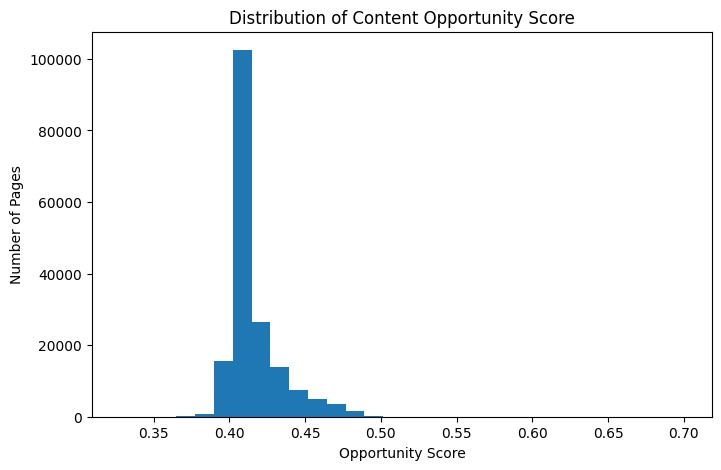

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(content_df["opportunity_score"], bins=30)

plt.title("Distribution of Content Opportunity Score")
plt.xlabel("Opportunity Score")
plt.ylabel("Number of Pages")

plt.show()

#CTR Distribution

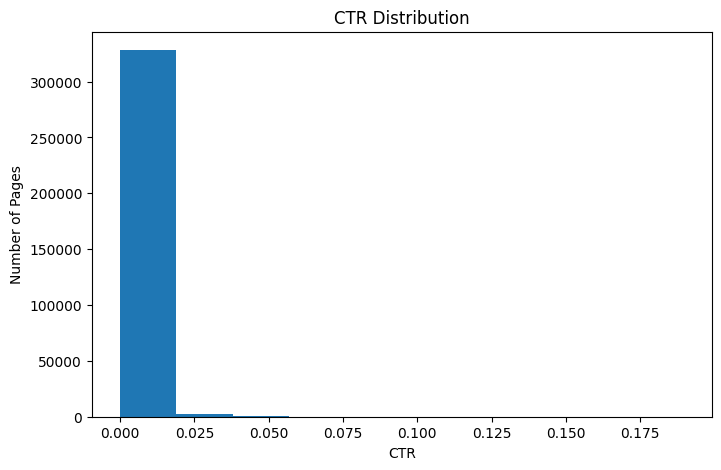

In [72]:
plt.figure(figsize=(8,5))

plt.hist(content_df["ctr"], bins=10)

plt.title("CTR Distribution")
plt.xlabel("CTR")
plt.ylabel("Number of Pages")

plt.show()

#Impressions vs CTR

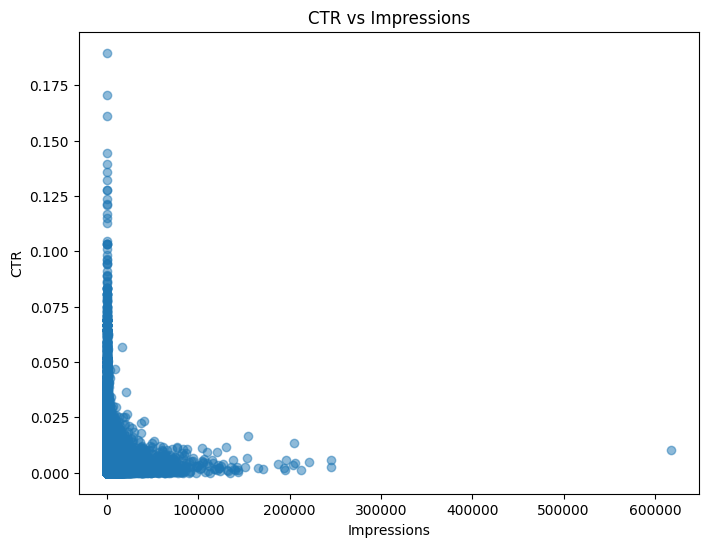

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    content_df["gsc_impressions"],
    content_df["ctr"],
    alpha=0.5
)

plt.title("CTR vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("CTR")

plt.show()

#Top 20 Opportunity Pages

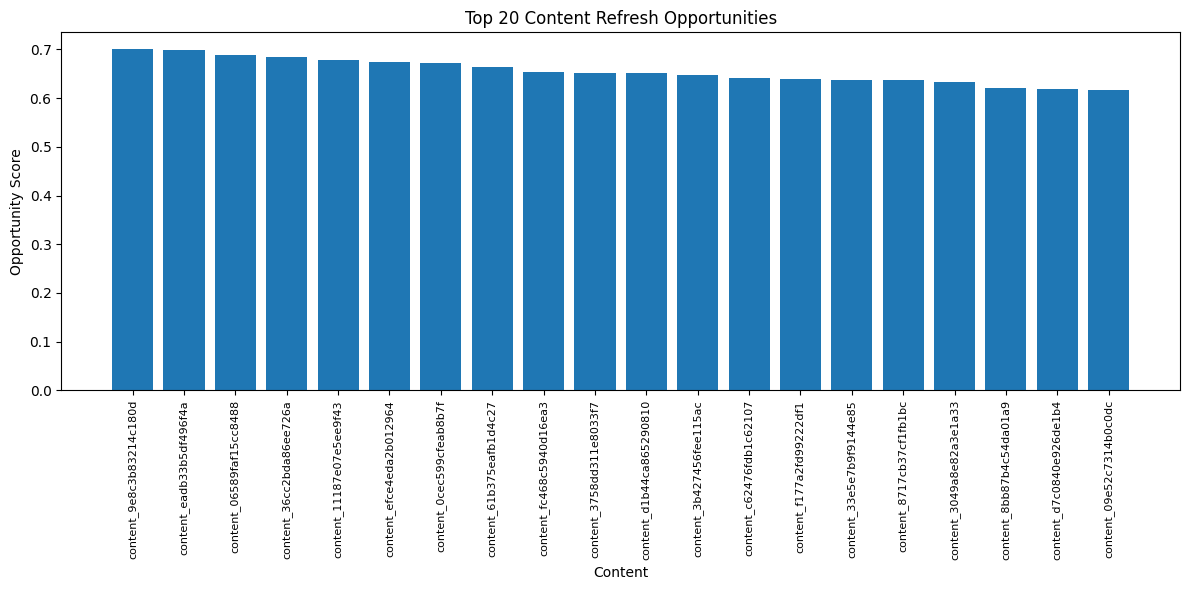

In [74]:
top20 = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top20)),
    top20["opportunity_score"]
)

plt.xticks(
    range(len(top20)),
    top20["content_hash_id"],
    rotation=90,
    fontsize=8
)

plt.title("Top 20 Content Refresh Opportunities")
plt.xlabel("Content")
plt.ylabel("Opportunity Score")

plt.tight_layout()

plt.show()

#Correlation Heatmap

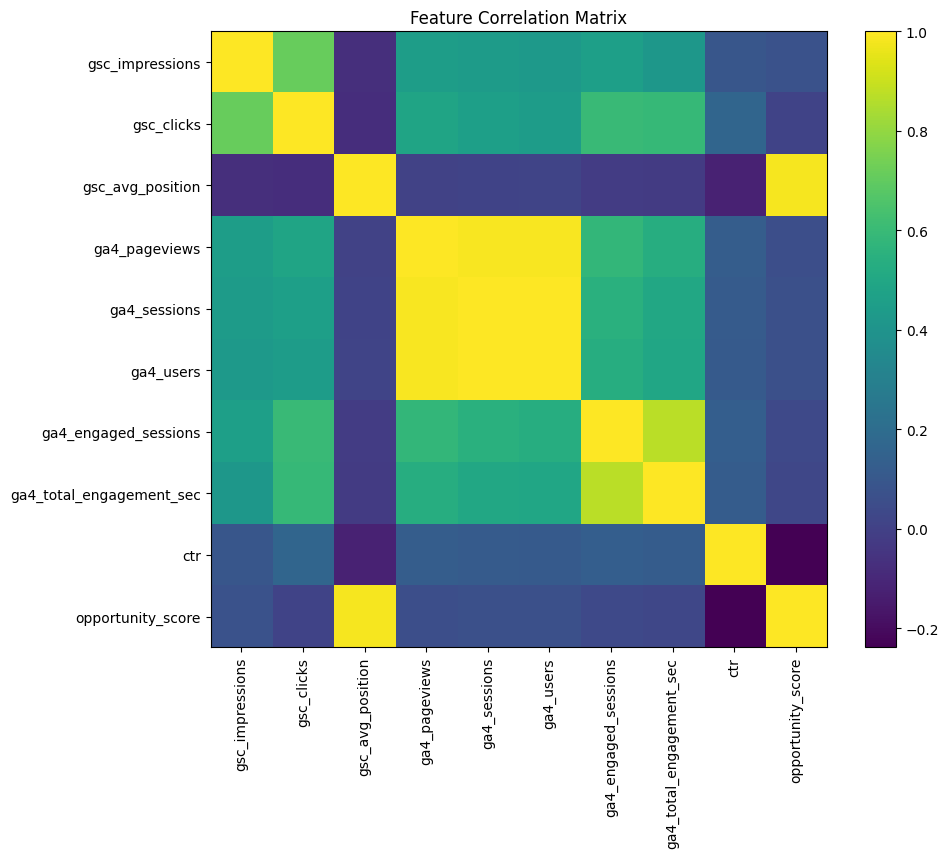

In [75]:
import matplotlib.pyplot as plt

cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "ctr",
    "opportunity_score"
]

corr = content_df[cols].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks(range(len(cols)), cols)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

#Results Summary

## Summary

The baseline prioritizes content solely based on search impressions. In contrast, the proposed Content Opportunity Score incorporates multiple search performance signals, enabling a more comprehensive ranking of pages that may benefit from review.

Pages with high opportunity scores generally combine high visibility with relatively lower click-through rates or weaker average positions, making them suitable candidates for content refresh.

These findings are intended to support decision-making and should be interpreted as observational rather than causal.

## 5. Limitations

*What this work cannot claim.*

# Limitations

- Results are observational.
- Correlation does not imply causation.
- The model supports decision-making but does not explain Google's ranking algorithm.
- Only available warehouse data was analyzed.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 6. Ranked Recommendations

Based on the Content Opportunity Score, the following actions are recommended.

1. Prioritize pages with high impressions but low CTR for title and meta description improvements.
2. Review pages with declining average search position to identify content gaps.
3. Refresh pages with strong visibility but low engagement.
4. Continue monitoring high-performing pages to maintain performance.
5. Re-evaluate pages with consistently low visibility before investing additional resources.

These recommendations are intended to support content strategy and should be validated by domain experts before implementation.

In [76]:
recommendations = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .copy()
)

recommendations["Recommended Action"] = "Refresh Content"

recommendations[
    [
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr",
        "gsc_avg_position",
        "opportunity_score",
        "Recommended Action"
    ]
]

,content_hash_id,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,opportunity_score,Recommended Action
205205,content_9e8c3b83214c180d,1,0,0.000000,309.000000,0.700000,Refresh Content
304000,content_eadb33b5df496f4a,617124,5668,0.010076,2.383011,0.698283,Refresh Content
8166,content_06589faf15cc8488,1,0,0.000000,297.000000,0.688350,Refresh Content
70522,content_36cc2bda86ee726a,1,0,0.000000,292.000000,0.683496,Refresh Content
22138,content_11187e07e5ee9f43,1,0,0.000000,286.000000,0.677670,Refresh Content
310341,content_efce4eda2b012964,1,0,0.000000,283.000000,0.674758,Refresh Content
16691,content_0cec599cfeab8b7f,1,0,0.000000,280.000000,0.671845,Refresh Content
126138,content_61b375eafb1d4c27,1,0,0.000000,271.000000,0.663107,Refresh Content
326564,content_fc468c5940d16ea3,1,0,0.000000,262.000000,0.654369,Refresh Content
71280,content_3758dd311e8033f7,1,0,0.000000,260.000000,0.652428,Refresh Content


#Top 20 Recommendations

In [77]:
recommendations = (
    content_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .copy()
)

recommendations["Recommended Action"] = "Refresh Content"

recommendations[
    [
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr",
        "gsc_avg_position",
        "opportunity_score",
        "Recommended Action"
    ]
]

,content_hash_id,gsc_impressions,gsc_clicks,ctr,gsc_avg_position,opportunity_score,Recommended Action
205205,content_9e8c3b83214c180d,1,0,0.000000,309.000000,0.700000,Refresh Content
304000,content_eadb33b5df496f4a,617124,5668,0.010076,2.383011,0.698283,Refresh Content
8166,content_06589faf15cc8488,1,0,0.000000,297.000000,0.688350,Refresh Content
70522,content_36cc2bda86ee726a,1,0,0.000000,292.000000,0.683496,Refresh Content
22138,content_11187e07e5ee9f43,1,0,0.000000,286.000000,0.677670,Refresh Content
310341,content_efce4eda2b012964,1,0,0.000000,283.000000,0.674758,Refresh Content
16691,content_0cec599cfeab8b7f,1,0,0.000000,280.000000,0.671845,Refresh Content
126138,content_61b375eafb1d4c27,1,0,0.000000,271.000000,0.663107,Refresh Content
326564,content_fc468c5940d16ea3,1,0,0.000000,262.000000,0.654369,Refresh Content
71280,content_3758dd311e8033f7,1,0,0.000000,260.000000,0.652428,Refresh Content


In [78]:
recommendations.to_csv(
    "top20_content_recommendations.csv",
    index=False
)

print("Top 20 recommendations saved successfully.")

Top 20 recommendations saved successfully.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# Charts and Tables

- Dataset overview
- Missing values
- Feature distributions
- Correlation heatmap
- Feature importance
- Model comparison table
- Top 20 content opportunities

#Save Figures

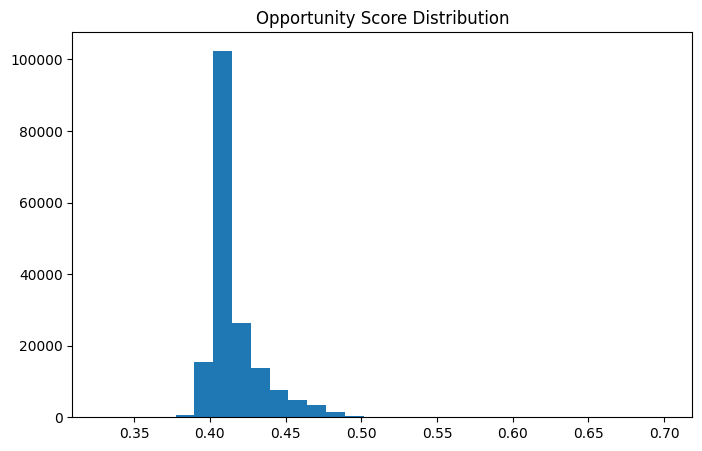

In [79]:
plt.figure(figsize=(8,5))

plt.hist(content_df["opportunity_score"], bins=30)

plt.title("Opportunity Score Distribution")

plt.savefig(
    "opportunity_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

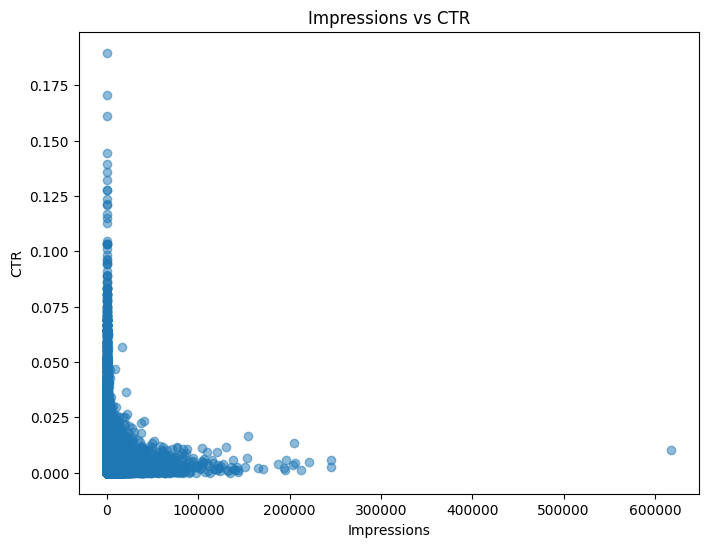

In [80]:
plt.figure(figsize=(8,6))

plt.scatter(
    content_df["gsc_impressions"],
    content_df["ctr"],
    alpha=0.5
)

plt.xlabel("Impressions")
plt.ylabel("CTR")
plt.title("Impressions vs CTR")

plt.savefig(
    "impressions_vs_ctr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

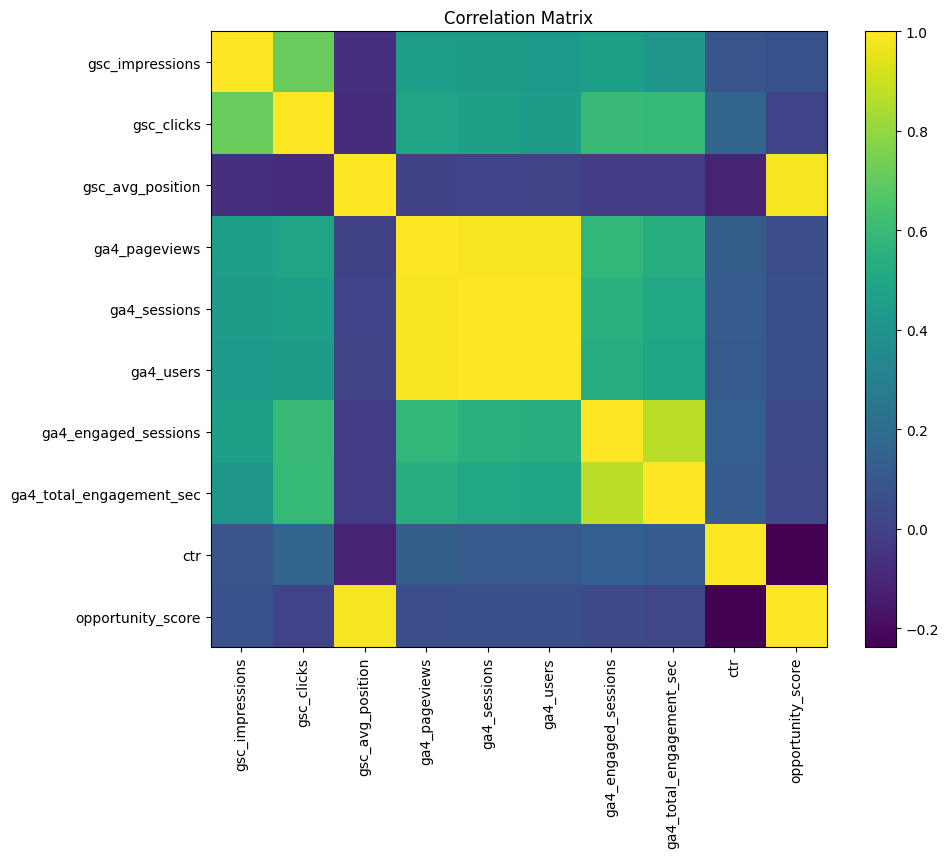

In [81]:
plt.figure(figsize=(10,8))

corr = content_df[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_sessions",
        "ga4_users",
        "ga4_engaged_sessions",
        "ga4_total_engagement_sec",
        "ctr",
        "opportunity_score"
    ]
].corr()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
content_df["gsc_avg_position"] = content_df["gsc_avg_position"].fillna(
    content_df["gsc_avg_position"].median()
)
content_df["opportunity_score"]=content_df["opportunity_score"].fillna(
    content_df["opportunity_score"].median()
)

#Step 1: Prepare Features

In [83]:
from sklearn.model_selection import train_test_split

features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "ctr"
]

X = content_df[features]

y = content_df["opportunity_score"]

#Step 2: Train-Test Split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (265149, 9)
Testing : (66288, 9)


#Step 3: Baseline Model

In [85]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [86]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [87]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate(name, y_true, pred):

    print(f"\n{name}")

    print(
        "MAE:",
        mean_absolute_error(y_true, pred)
    )

    print(
        "RMSE:",
        mean_squared_error(
            y_true,
            pred
        ) ** 0.5
    )

    print(
        "R²:",
        r2_score(
            y_true,
            pred
        )
    )

evaluate(
    "Baseline",
    y_test,
    baseline_pred
)

evaluate(
    "Random Forest",
    y_test,
    rf_pred
)


Baseline
MAE: 0.007899950864431344
RMSE: 0.013177616021443328
R²: -1.5453705493051473e-07

Random Forest
MAE: 2.5133065828791143e-05
RMSE: 0.0001863798564182339
R²: 0.9997999565593785


In [88]:
results = {
    "Model": [],
    "MAE": [],
    "RMSE": [],
    "R2": []
}

for name, pred in [
    ("Baseline", baseline_pred),
    ("Random Forest", rf_pred)
]:

    results["Model"].append(name)

    results["MAE"].append(
        mean_absolute_error(y_test, pred)
    )

    results["RMSE"].append(
        mean_squared_error(
            y_test,
            pred
        ) ** 0.5
    )

    results["R2"].append(
        r2_score(
            y_test,
            pred
        )
    )

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Baseline,0.007900,0.013178,-1.545371e-07
1,Random Forest,0.000025,0.000186,9.998000e-01


In [89]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
2,gsc_avg_position,0.966299
0,gsc_impressions,0.017380
8,ctr,0.015064
1,gsc_clicks,0.000361
3,ga4_pageviews,0.000267
7,ga4_total_engagement_sec,0.000257
5,ga4_users,0.000152
6,ga4_engaged_sessions,0.000132
4,ga4_sessions,0.000088


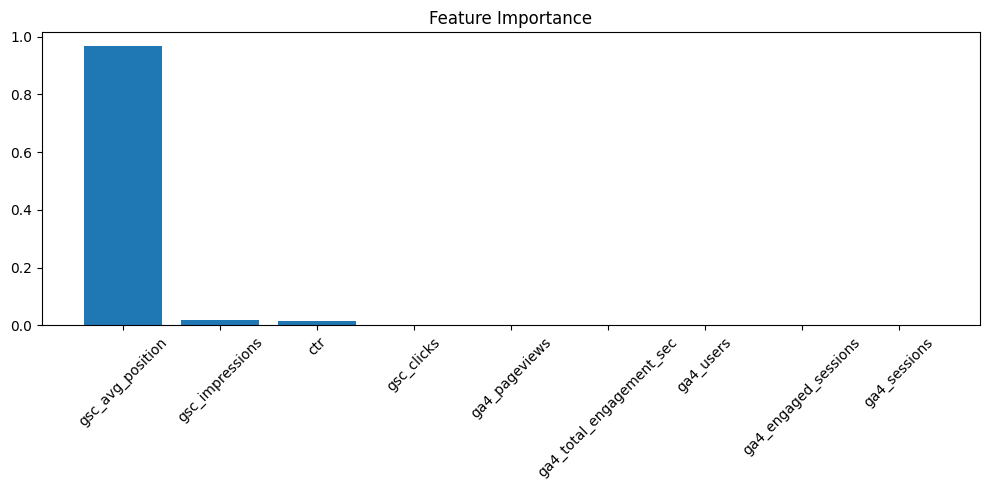

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [91]:
print(df["report_date"].min())
print(df["report_date"].max())

print(
    df["report_date"]
    .sort_values()
    .unique()
)

2026-03-01 00:00:00
2026-03-31 00:00:00
<DatetimeArray>
['2026-03-01 00:00:00', '2026-03-02 00:00:00', '2026-03-03 00:00:00',
 '2026-03-04 00:00:00', '2026-03-05 00:00:00', '2026-03-06 00:00:00',
 '2026-03-07 00:00:00', '2026-03-08 00:00:00', '2026-03-09 00:00:00',
 '2026-03-10 00:00:00', '2026-03-11 00:00:00', '2026-03-12 00:00:00',
 '2026-03-13 00:00:00', '2026-03-14 00:00:00', '2026-03-15 00:00:00',
 '2026-03-16 00:00:00', '2026-03-17 00:00:00', '2026-03-18 00:00:00',
 '2026-03-19 00:00:00', '2026-03-20 00:00:00', '2026-03-21 00:00:00',
 '2026-03-22 00:00:00', '2026-03-23 00:00:00', '2026-03-24 00:00:00',
 '2026-03-25 00:00:00', '2026-03-26 00:00:00', '2026-03-27 00:00:00',
 '2026-03-28 00:00:00', '2026-03-29 00:00:00', '2026-03-30 00:00:00',
 '2026-03-31 00:00:00']
Length: 31, dtype: datetime64[us]


In [92]:
df["report_date"] = pd.to_datetime(df["report_date"])

df = df.sort_values("report_date")

print(df["report_date"].min())
print(df["report_date"].max())

2026-03-01 00:00:00
2026-03-31 00:00:00


In [93]:
cutoff_date = pd.Timestamp("2026-03-21")

past_df = df[df["report_date"] <= cutoff_date].copy()
future_df = df[df["report_date"] > cutoff_date].copy()

print("Past data:", past_df.shape)
print("Future data:", future_df.shape)

print("Past:", past_df["report_date"].min(), "to", past_df["report_date"].max())
print("Future:", future_df["report_date"].min(), "to", future_df["report_date"].max())

Past data: (6573997, 11)
Future data: (3267381, 11)
Past: 2026-03-01 00:00:00 to 2026-03-21 00:00:00
Future: 2026-03-22 00:00:00 to 2026-03-31 00:00:00


In [94]:
past_features = (
    past_df.groupby("content_hash_id")
    .agg(
        past_impressions=("gsc_impressions", "sum"),
        past_clicks=("gsc_clicks", "sum"),
        past_avg_position=("gsc_avg_position", "mean"),
        past_pageviews=("ga4_pageviews", "sum"),
        past_sessions=("ga4_sessions", "sum"),
        past_users=("ga4_users", "sum"),
        past_engaged_sessions=("ga4_engaged_sessions", "sum"),
        past_engagement_sec=("ga4_total_engagement_sec", "sum")
    )
    .reset_index()
)

In [95]:
past_features["past_ctr"] = np.where(
    past_features["past_impressions"] > 0,
    past_features["past_clicks"] / past_features["past_impressions"],
    0
)

In [96]:
past_features.head()

,content_hash_id,past_impressions,past_clicks,past_avg_position,past_pageviews,past_sessions,past_users,past_engaged_sessions,past_engagement_sec,past_ctr
0,content_000005d4ced12088,37,0,50.103968,0,0,0,0,0,0.0
1,content_00001e488b74b799,0,0,7.500000,0,0,0,0,0,0.0
2,content_00007bd2985b77c3,30,0,7.176190,0,0,0,0,0,0.0
3,content_00008950670cb6b5,0,0,7.500000,1,1,1,0,0,0.0
4,content_0000a348850eb1fc,0,0,7.500000,1,1,1,0,7,0.0


In [97]:
future_target = (
    future_df.groupby("content_hash_id")
    .agg(
        future_impressions=("gsc_impressions", "sum"),
        future_clicks=("gsc_clicks", "sum"),
        future_avg_position=("gsc_avg_position", "mean"),
        future_pageviews=("ga4_pageviews", "sum"),
        future_sessions=("ga4_sessions", "sum"),
        future_engaged_sessions=("ga4_engaged_sessions", "sum")
    )
    .reset_index()
)

In [98]:
future_target["future_ctr"] = np.where(
    future_target["future_impressions"] > 0,
    future_target["future_clicks"] /
    future_target["future_impressions"],
    0
)

In [99]:
model_df = past_features.merge(
    future_target,
    on="content_hash_id",
    how="inner"
)

print(model_df.shape)
model_df.head()

(324296, 17)


,content_hash_id,past_impressions,past_clicks,past_avg_position,past_pageviews,past_sessions,past_users,past_engaged_sessions,past_engagement_sec,past_ctr,future_impressions,future_clicks,future_avg_position,future_pageviews,future_sessions,future_engaged_sessions,future_ctr
0,content_000005d4ced12088,37,0,50.103968,0,0,0,0,0,0.0,49,0,74.883333,0,0,0,0.0
1,content_00001e488b74b799,0,0,7.500000,0,0,0,0,0,0.0,0,0,7.500000,0,0,0,0.0
2,content_00007bd2985b77c3,30,0,7.176190,0,0,0,0,0,0.0,17,0,3.050000,0,0,0,0.0
3,content_00008950670cb6b5,0,0,7.500000,1,1,1,0,0,0.0,0,0,7.500000,1,1,1,0.0
4,content_0000a348850eb1fc,0,0,7.500000,1,1,1,0,7,0.0,0,0,7.500000,0,0,0,0.0


In [100]:
X = model_df[
    [
        "past_impressions",
        "past_clicks",
        "past_avg_position",
        "past_pageviews",
        "past_sessions",
        "past_users",
        "past_engaged_sessions",
        "past_engagement_sec",
        "past_ctr"
    ]
]

y = model_df["future_ctr"]

print("X:", X.shape)
print("y:", y.shape)

X: (324296, 9)
y: (324296,)


In [101]:
print(model_df.shape)
print(y.describe())

(324296, 17)
count    324296.000000
mean          0.001762
std           0.023556
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: future_ctr, dtype: float64


In [102]:
print(model_df["future_clicks"].describe())

count    324296.000000
mean          0.858589
std           7.512402
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2270.000000
Name: future_clicks, dtype: float64


In [103]:
print(
    model_df["future_clicks"]
    .value_counts()
    .sort_index()
    .head(20)
)

future_clicks
0     279111
1      17173
2       7276
3       4317
4       2818
5       2002
6       1552
7       1277
8        975
9        769
10       686
11       532
12       473
13       401
14      1202
15       300
16       242
17       246
18       225
19       180
Name: count, dtype: int64


In [104]:
threshold = model_df["future_clicks"].quantile(0.90)

print("Threshold:", threshold)

Threshold: 1.0


In [105]:
model_df["opportunity_label"] = (
    model_df["future_clicks"] >= threshold
).astype(int)

print(
    model_df["opportunity_label"].value_counts()
)

opportunity_label
0    279111
1     45185
Name: count, dtype: int64


In [106]:
print(model_df["future_clicks"].describe())

count    324296.000000
mean          0.858589
std           7.512402
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2270.000000
Name: future_clicks, dtype: float64


In [107]:
print(
    model_df["future_clicks"]
    .value_counts()
    .sort_index()
    .head(20)
)

future_clicks
0     279111
1      17173
2       7276
3       4317
4       2818
5       2002
6       1552
7       1277
8        975
9        769
10       686
11       532
12       473
13       401
14      1202
15       300
16       242
17       246
18       225
19       180
Name: count, dtype: int64


In [108]:
features = [
    "past_impressions",
    "past_clicks",
    "past_avg_position",
    "past_pageviews",
    "past_sessions",
    "past_users",
    "past_engaged_sessions",
    "past_engagement_sec",
    "past_ctr"
]

X = model_df[features].copy()
y = model_df["opportunity_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (324296, 9)
y shape: (324296,)

Class distribution:
opportunity_label
0    279111
1     45185
Name: count, dtype: int64


In [109]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X, y)

baseline_pred = baseline.predict(X)

print("Baseline positive predictions:",
      baseline_pred.sum())

Baseline positive predictions: 0


In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X, y)

model_pred = rf.predict(X)

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (259436, 9)
Validation: (64860, 9)


In [112]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

In [113]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_prob = rf.predict_proba(X_val)[:, 1]

In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(name, y_true, pred, prob):

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall   :", recall_score(y_true, pred, zero_division=0))
    print("F1       :", f1_score(y_true, pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_true, prob))
    print("PR-AUC   :", average_precision_score(y_true, prob))


evaluate_model(
    "Baseline",
    y_val,
    baseline_pred,
    baseline_prob
)

evaluate_model(
    "Random Forest",
    y_val,
    rf_pred,
    rf_prob
)


Baseline
----------------------------------------
Accuracy : 0.8606691335183472
Precision: 0.0
Recall   : 0.0
F1       : 0.0
ROC-AUC  : 0.5
PR-AUC   : 0.1393308664816528

Random Forest
----------------------------------------
Accuracy : 0.9199352451433858
Precision: 0.7509138381201045
Recall   : 0.6364944118623437
F1       : 0.6889860453973767
ROC-AUC  : 0.9014368844097694
PR-AUC   : 0.7658919439637246


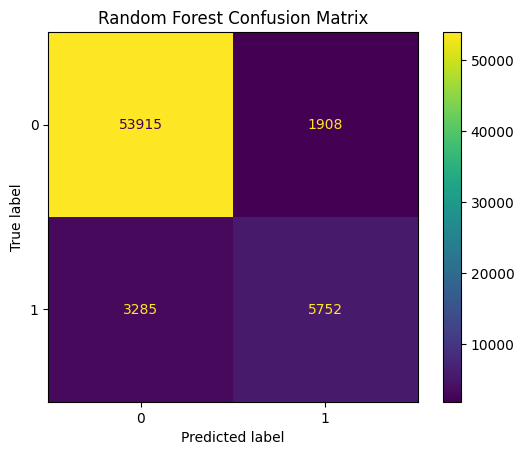

In [115]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.